In [100]:
import numpy as np
import pandas as pd
from skimage import io, measure
import matplotlib.pyplot as plt

from pathlib import Path
import stackview

In [105]:
dirname = Path('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/TRU-FACT/Matched/Skin_aligned_HCR_RAW/40x_K10_exvivo')

flattened_mem = io.imread(dirname / 'flattened_mem.tif')
flattened_k10 = io.imread(dirname / 'flattened_k10.tif')
stackview.slice(flattened_k10,zoom_factor=0.3)


/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_75045/2516661889.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(curvature)


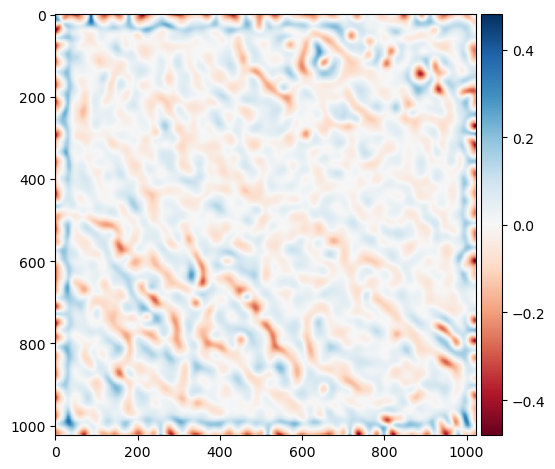

In [129]:
curvature = io.imread(dirname / '08_cellmask_boundary/part1_boundary_extraction/prediction_curvature.tif') /.4
io.imshow(curvature)
curvature_stack = np.stack([curvature] * basal_masks.shape[0])

In [166]:
basal_masks = io.imread(dirname / 'basal_cells.tif')
stackview.slice(basal_masks,zoom_factor=0.3)

In [167]:
def approx_apical_area(mask):
    return mask[0:3,...].max(axis=0).sum()
def approx_basal_area(mask):
    return mask[-3:,...].max(axis=0).sum()

df = pd.DataFrame(measure.regionprops_table(
    basal_masks,intensity_image=flattened_k10,properties=['label','area','mean_intensity'],
    extra_properties=[approx_basal_area,approx_apical_area]))
df = df.rename(columns={'mean_intensity':'K10'})
df = pd.merge(df,pd.DataFrame(measure.regionprops_table(
    basal_masks,intensity_image=curvature_stack,properties=['mean_intensity'])),
             left_index=True,right_index=True)
df = df.rename(columns={'mean_intensity':'curvature'})
df = pd.merge(df,pd.DataFrame(measure.regionprops_table(
    basal_masks,intensity_image=flattened_mem,properties=['mean_intensity'])),
             left_index=True,right_index=True)
df = df.rename(columns={'mean_intensity':'mem'})
df['Log-K10'] = np.log(df['K10'])

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


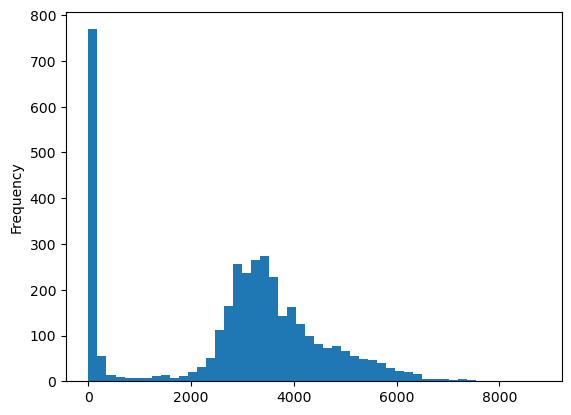

In [168]:
# Filter by area
df['area'].plot.hist(bins=50)
threshold = 1000
df = df[df['area'] > threshold]

In [162]:
import seaborn as sb

threshold = 8.75

df['K10 pos'] = False
df.loc[df['Log-K10'] > threshold,'K10 pos'] = True
df['K10 pos'].sum() / len(df)

np.float64(0.210896309314587)

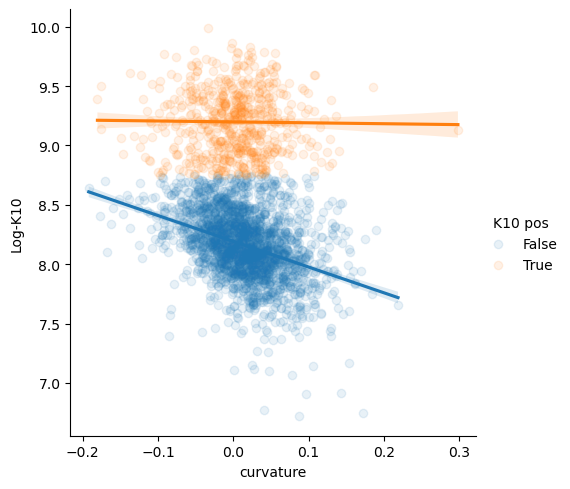

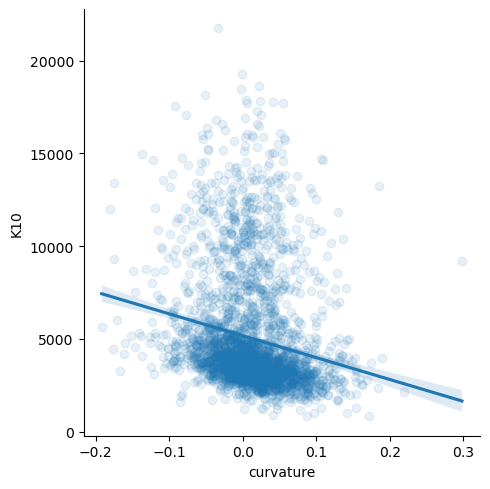

In [163]:
# sb.lmplot(df,x='curvature',y='K10',scatter_kws={'alpha':0.1},hue='K10 pos')
sb.lmplot(df,x='curvature',y='Log-K10',scatter_kws={'alpha':0.1},hue='K10 pos')

sb.lmplot(df,x='curvature',y='K10',scatter_kws={'alpha':0.1})

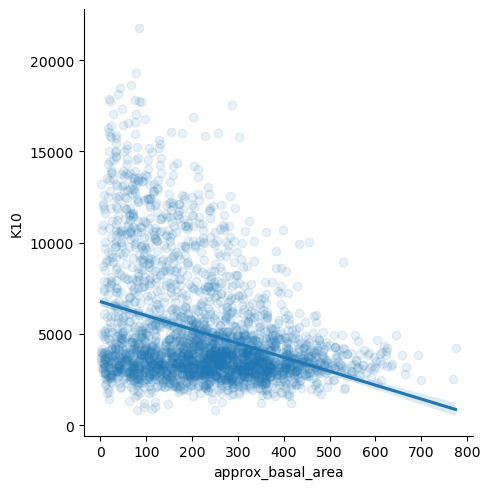

In [164]:
sb.lmplot(df,x='approx_basal_area',y='K10',scatter_kws={'alpha':0.1})


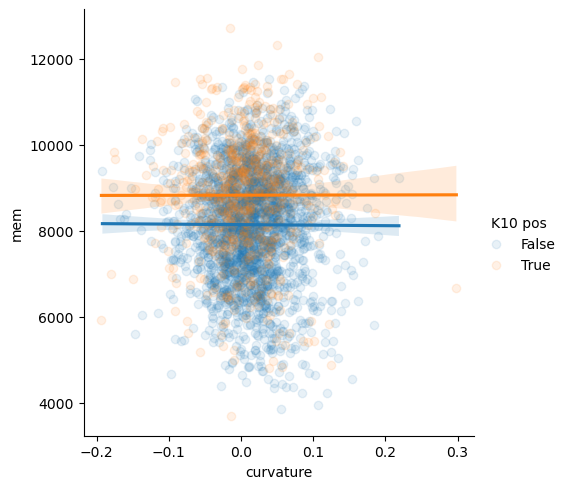

In [157]:
sb.lmplot(df,x='curvature',y='mem',scatter_kws={'alpha':0.1},hue='K10 pos')


In [165]:
# Back form the cell masks from k10_high and k10_low

k10_neg_masks = np.zeros_like(basal_masks)
for l in df[~df['K10 pos']]['label'].unique()[1:]:
    k10_neg_masks[basal_masks == l] = l
io.imsave(dirname / 'k10_neg_masks.tif',k10_neg_masks)

k10_pos_masks = np.zeros_like(basal_masks)
for l in df[df['K10 pos']]['label'].unique()[1:]:
    k10_pos_masks[basal_masks == l] = l

io.imsave(dirname / 'k10_pos_masks.tif',k10_pos_masks)

/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/TRU-FACT/Matched/Skin_aligned_HCR_RAW/40x_K10_exvivo/k10_neg_masks.tif is a low contrast image
  return func(*args, **kwargs)
/opt/miniconda3/envs/jupyter/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: /Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/TRU-FACT/Matched/Skin_aligned_HCR_RAW/40x_K10_exvivo/k10_pos_masks.tif is a low contrast image
  return func(*args, **kwargs)
